Import Library & Load Dataset

In [1]:
!pip install pandas scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load dataset (pastikan file marketing_campaign.csv sudah diupload ke Colab)
df = pd.read_csv("marketing_campaign.csv", sep="\t")


df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


Data Processing

In [2]:
# Cek missing values
print(df.isnull().sum())

# Hapus baris dengan missing Income
df = df.dropna(subset=["Income"])

# Hapus duplikasi
df = df.drop_duplicates()

# Pilih fitur numerik untuk clustering
features = ["Year_Birth","Income","Kidhome","Teenhome","Recency",
            "MntWines","MntMeatProducts","MntFishProducts",
            "MntSweetProducts","MntGoldProds"]

X = df[features]

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64


Dimension Reduction (PCA)

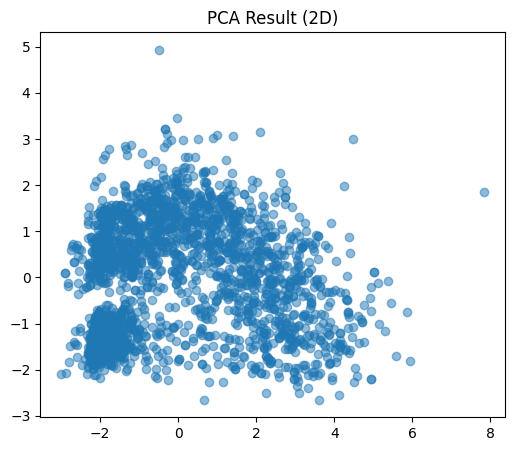

In [3]:
# PCA untuk reduksi dimensi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("PCA Result (2D)")
plt.show()

Clustering Model (K-Means)

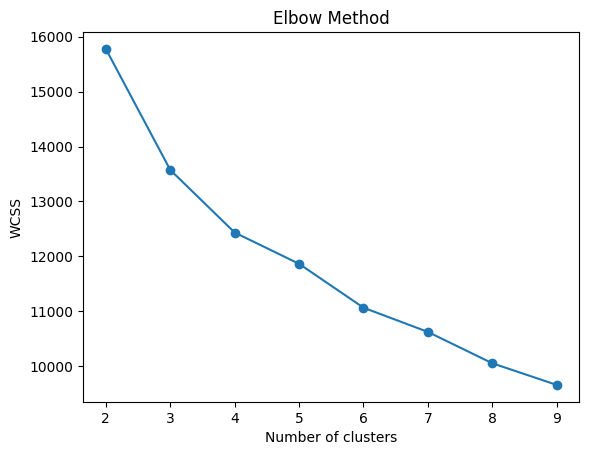

In [4]:
# Tentukan jumlah cluster dengan Elbow Method
wcss = []
for i in range(2,10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,10), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

# Misal pilih 4 cluster
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

Model Evaluation

Silhouette Score: 0.1893127860069284


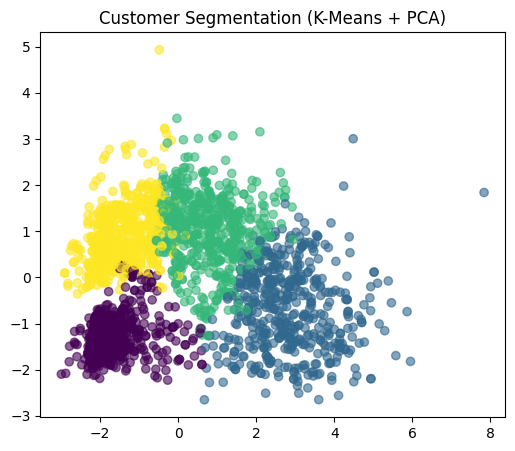

In [5]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

# Visualisasi cluster hasil PCA
plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis", alpha=0.6)
plt.title("Customer Segmentation (K-Means + PCA)")
plt.show()

Customer Segmentation

In [6]:
# Lihat rata-rata tiap cluster
cluster_summary = df.groupby("Cluster")[features].mean()
print(cluster_summary)

# Interpretasi manual:
# Cluster 0 → pelanggan muda dengan pengeluaran tinggi
# Cluster 1 → pelanggan menengah dengan pengeluaran moderat
# Cluster 2 → pelanggan tua dengan income rendah
# Cluster 3 → pelanggan loyal dengan spending seimbang

          Year_Birth        Income   Kidhome  Teenhome    Recency    MntWines  \
Cluster                                                                         
0        1978.260135  30609.366554  0.841216  0.000000  48.972973   46.758446   
1        1969.350305  77734.232179  0.059063  0.142566  49.421589  600.890020   
2        1963.404806  62777.158965  0.062847  0.826248  49.036969  545.000000   
3        1963.890203  43123.670608  0.706081  1.018581  48.690878   98.851351   

         MntMeatProducts  MntFishProducts  MntSweetProducts  MntGoldProds  
Cluster                                                                    
0              33.179054        11.042230          7.673986     19.932432  
1             486.126273       111.749491         78.513238     81.175153  
2             169.722736        33.556377         26.060998     66.399261  
3              33.636824         6.494932          4.567568     16.635135  
